This script visualizes daily temperatures calculated using driver data from the example folder and measured data from the corresponding permafrost monitoring station.

In [31]:
%matplotlib inline
import numpy as np
import pandas as pd
import subprocess
from matplotlib import pyplot as plt
import yaml
import os
from pathlib import Path
GIPL_PATH = Path(f"{os.getenv('HOME')}/GIPL")
print(GIPL_PATH)
WD_PATH = Path(f"{os.getcwd()}")
print(WD_PATH)
ROOT_OUTPUT_PATH = Path(f"{os.getenv('HOME')}/gipl_experiments")
print(ROOT_OUTPUT_PATH)
config_file = WD_PATH/'gipl_config.cfg'
print(Path(config_file))

/home/awelch/GIPL
/home/awelch/GIPL/calibration_run
/home/awelch/gipl_experiments
/home/awelch/GIPL/calibration_run/gipl_config.cfg


/home/awelch/GIPL/calibration_run/in/bound.txt


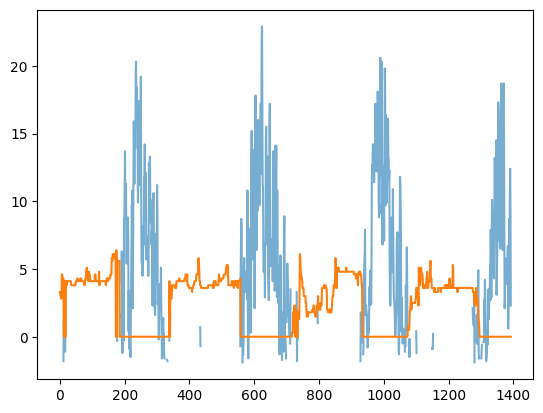

In [32]:
ubound_file=WD_PATH/'in/bound.txt'
print(Path(ubound_file))
ubound = np.loadtxt(ubound_file, skiprows=1,  unpack=False)
df_tair = pd.DataFrame(ubound[:,-1:], columns=['Tair [C]']) 

snow_file=WD_PATH/'in/snow.txt'
dsnow = np.loadtxt(snow_file, skiprows=1,  unpack=False)
df_dsnow = pd.DataFrame(dsnow[:,-1:], columns=['snow depth[m]']) 

rsnow_file=WD_PATH/'in/rsnow.txt'
rsnow = np.loadtxt(rsnow_file, skiprows=1,  unpack=False)
df_rsnow = pd.DataFrame(rsnow[:,-1:], columns=['snow cond[W/m/K]']) 

plt.plot(df_tair[df_tair>-2], alpha=0.6)
plt.plot(df_dsnow*10)

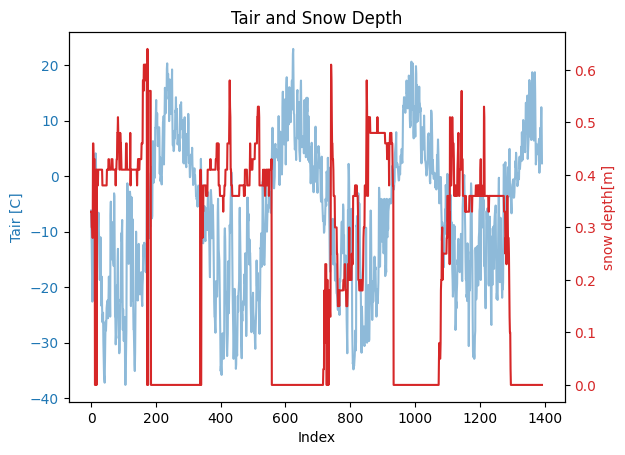

In [33]:
# Ensure that the indices match or align them if necessary
df_tair.index = pd.RangeIndex(start=0, stop=len(df_tair), step=1)
df_dsnow.index = pd.RangeIndex(start=0, stop=len(df_dsnow), step=1)

# Create the plot with two y-axes
fig, ax1 = plt.subplots()

# Plot the first dataset on the primary y-axis
ax1.plot(df_tair.index, df_tair['Tair [C]'], color='tab:blue', alpha=0.5)
ax1.set_xlabel('Index')
ax1.set_ylabel('Tair [C]', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Create a secondary y-axis and plot the second dataset
ax2 = ax1.twinx()
ax2.plot(df_dsnow.index, df_dsnow['snow depth[m]'], color='tab:red')
ax2.set_ylabel('snow depth[m]', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

# Add a title and show the plot
plt.title('Tair and Snow Depth')
plt.show()

In [34]:
def load_calc():
    calc_file=WD_PATH/'out/result.txt'
    calc_data = np.loadtxt(calc_file, skiprows=0,  unpack=False)
    calc_header=['id','time','Tair','snow','0.01m', '0.08m', '0.13m', '0.24m', '0.38m', '0.53m', '0.67m' ]
    df = pd.DataFrame(calc_data, columns=calc_header) 
    return df

def load_meas():
    meas_file=WD_PATH/'data/mesres.txt'
    df_meas =  np.loadtxt(meas_file, skiprows=0,  unpack=False)#pd.read_csv(meas_file)
    df = pd.DataFrame(df_meas, columns=['0.01m', '0.08m', '0.13m', '0.24m', '0.38m', '0.53m', '0.67m'])
    df_365 = df.head(365)
    return df_365

df_calc=load_calc()
df_meas=load_meas()

Text(0.5, 1.0, 'Calculated ground temperatures ')

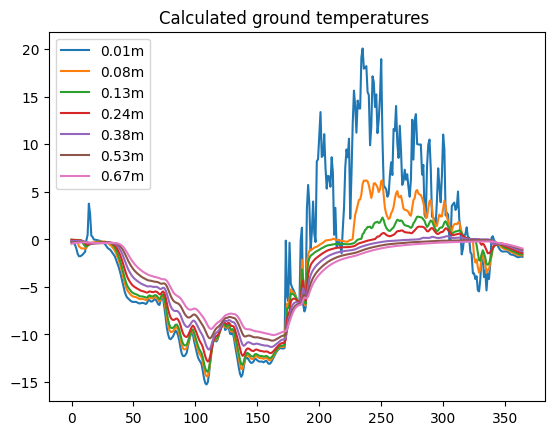

In [35]:
df_calc[['0.01m', '0.08m', '0.13m', '0.24m', '0.38m', '0.53m', '0.67m']].plot()
plt.title('Calculated ground temperatures ')

Text(0.5, 1.0, 'Measured ground temperatures ')

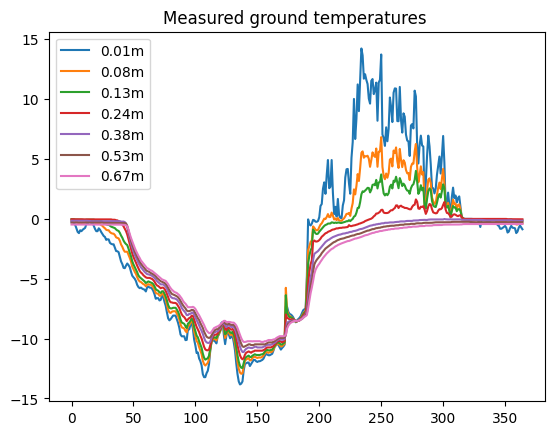

In [36]:
df_meas.plot()
plt.title('Measured ground temperatures ')

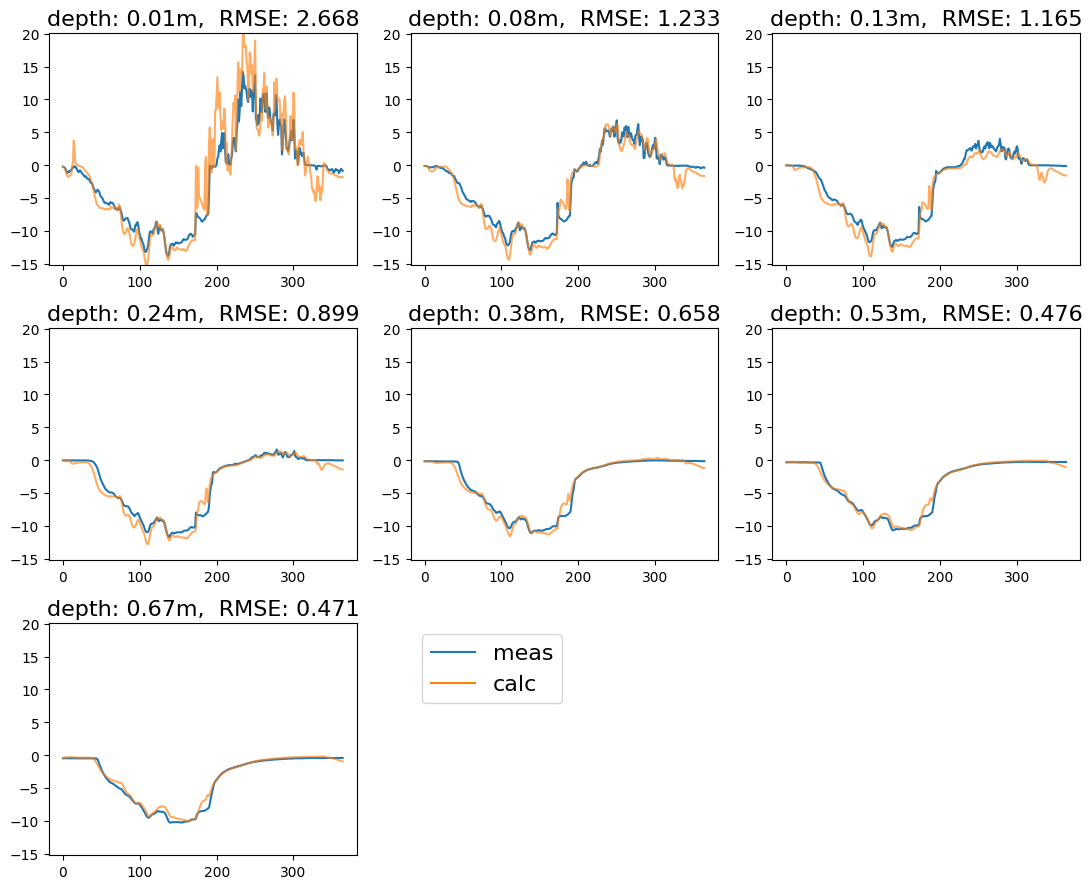

In [37]:
def determine_y_lims(hh1, hh2):
    df_calc1 = load_calc()
    df_meas1 = load_meas()
    df_calc2 = load_calc()
    df_meas2 = load_meas()

    df_meas1 = df_meas1.iloc[:len(df_calc1), :]
    df_meas2 = df_meas2.iloc[:len(df_calc2), :]

    min_y = min(df_meas1[hh1].min().min(), df_calc1[hh1].min().min(), 
                df_meas2[hh2].min().min(), df_calc2[hh2].min().min())
    max_y = max(df_meas1[hh1].max().max(), df_calc1[hh1].max().max(), 
                df_meas2[hh2].max().max(), df_calc2[hh2].max().max())

    return min_y, max_y                


def plot_ground_temps(hh, min_y, max_y):
    df_calc = load_calc()
    [ndays, ncols] = df_calc.shape
    df_meas = load_meas()
    df_meas = df_meas.iloc[:ndays, :]

    fig = plt.figure()
    fig.set_figheight(9)  # Increase figure height for 3x3 layout
    fig.set_figwidth(11)
    
    axes = []
    for i in range(9):  # Create 9 subplots
        ax = fig.add_subplot(3, 3, i + 1)
        axes.append(ax)
        if i < len(hh):
            ih = hh[i]
            RMSE = np.sqrt(np.mean((df_meas[ih] - df_calc[ih])**2))
            ax.set_title(f'depth: {ih},  RMSE: {round(RMSE, 3)}', fontsize=16)
            ax.plot(df_meas[ih])
            ax.plot(df_calc[ih], alpha=0.65)
            ax.set_ylim(min_y, max_y)
        else:
            ax.set_visible(False)
    
    # Create a dummy plot in the last empty subplot and place the legend there
    if len(hh) < 9:
        legend_ax = axes[len(hh)]
        legend_ax.set_visible(True)
        legend_ax.axis('off')
        legend_ax.plot([], [], label='meas')  # Add dummy plot for legend
        legend_ax.plot([], [], label='calc')  # Add dummy plot for legend
        legend_ax.legend(loc='upper left', bbox_to_anchor=(0, 1), fontsize=16)
    
    fig.tight_layout()
    return fig


hh1 = ['0.01m', '0.08m', '0.13m', '0.24m', '0.38m', '0.53m', '0.67m']
hh2 = ['0.01m', '0.08m', '0.13m', '0.24m', '0.38m', '0.53m', '0.67m']
min_y, max_y = determine_y_lims(hh1, hh2)

# subprocess.call([GIPL_PATH/"gipl", str(config_file)])
fig1 = plot_ground_temps(hh1, min_y, max_y)
# fig1.savefig('plot_shallow_layers.png')
plt.show(fig1)

<h5>Working with 1 year dataset</h5>
change end date in the gipl_config.cfg to 1.

In [ ]:
subprocess.call([GIPL_PATH/"gipl", str(config_file)])
hh=['0.24m', '0.38m', '0.53m', '0.67m']
plot_ground_temps(hh)

In [ ]:
subprocess.call([GIPL_PATH/"gipl", str(config_file)])
hh=['0.01m', '0.08m', '0.13m', '0.24m']
plot_ground_temps(hh)

In [ ]:
df_meas=load_meas()
ndays = 365
df_meas.iloc[:ndays,:4].plot()

<h4>Sensitivity analysis example</h4>

This part of the script depends on inputs and config.yaml in the top level GIPL directory (~/GIPL/). Run python3 sa_for_gipl.py inside GIPL directory.

In [34]:
def load_icalc(outpath):
    calc_file=outpath / "out/result.txt"
    # print(calc_file)
    calc_data = np.loadtxt(calc_file, skiprows=0,  unpack=False)
    calc_header=['id','time','Tair','snow','0.01m', '0.08m', '0.13m', '0.24m', '0.38m', '0.53m', '0.67m' ]
    df = pd.DataFrame(calc_data, columns=calc_header) 
    return df

def read_yaml():
    with open("config.yaml") as config_file:
        try:
            config = yaml.safe_load(config_file)
            return config
        except yaml.YAMLError as exc:
            print(exc)

def parse_config(config_data):
    perturbation_range = config_data.get("perturbation_range")
    n_samples = config_data.get("n_samples")
    data_matrix = config_data.get("data")[0]

    return perturbation_range, n_samples, data_matrix

perturbation_range, n_samples, data = parse_config(read_yaml())
print(ROOT_OUTPUT_PATH)

/home/awelch/gipl_experiments


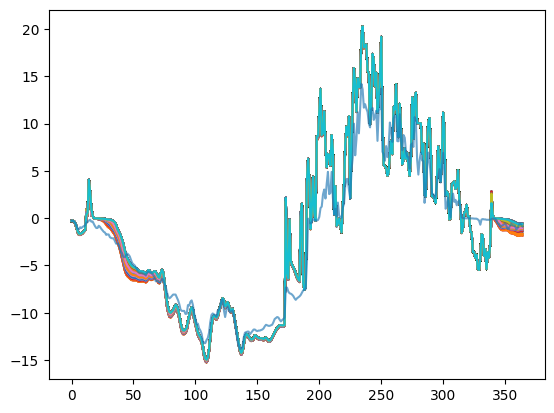

In [41]:
# run sensitivity analysis script
#!python sa_for_gipl.py
# read number of sample from config.yaml
depth = "0.01m"

perturbation_range, n_samples, data = parse_config(read_yaml())
# plot all samples for a given depth
rmse=[]
for sample in range(n_samples):
    isample=f"gipl_{sample}"
    ipath=ROOT_OUTPUT_PATH / isample
    # print(ipath)
    ires=load_icalc(ipath)
    rmse.append(np.sqrt(np.mean((ires[depth]-df_meas[depth].iloc[:365])**2)))
    plt.plot(ires[depth])
plt.plot(df_meas[depth].iloc[:365],alpha=0.65)  

In [42]:
#min(rmse)
val, idx = min((val, idx) for (idx, val) in enumerate(rmse))
val, idx

(np.float64(2.667695269618603), 24)

 1
1  6
0.4	0.34	-0.96	2510000.0	2240000.0	0.06	1.08	0.06
0.4	0.46	-0.22	2490000.0	2200000.0	0.13	0.64	0.02
0.35	0.11	-0.44	2490000.0	1920000.0	0.08	1.31	0.05
0.25	0.04	-0.13	2900000.0	1810000.0	0.5	0.97	4.48
0.41	0.05	-0.2	3100000.0	3000000.0	0.79	1.51	17.0
0.32	0.06	-0.65	3000000.0	2900000.0	2.0	2.1	8.0



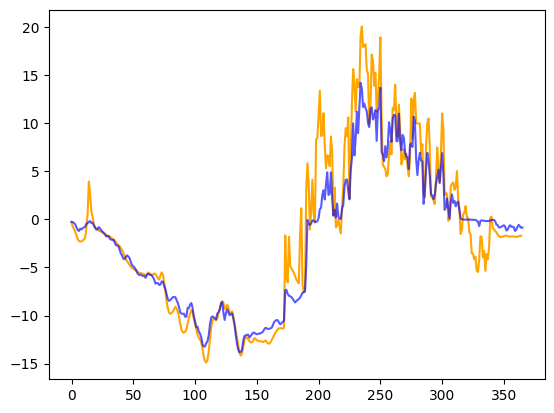

In [37]:
depth = "0.01m"

mineral_file = Path(f"~/gipl_experiments/gipl_{idx}/in/mineral.txt").expanduser()
with mineral_file.open() as file:
    contents = file.read()
    print(contents)

out_file = Path(f"~/gipl_experiments/gipl_{idx}").expanduser()

res=load_icalc(out_file)
rmse.append(np.sqrt(np.mean((res[depth]-df_meas[depth].loc[:365])**2)))
plt.plot(res[depth], color="orange")
plt.plot(df_meas[depth].loc[:365],alpha=0.65, color="blue") 

In [38]:
#min(combined rmse)
rmse_sums = []
depth_range = ['0.01m', '0.08m', '0.13m', '0.24m', '0.38m']
for sample in range(n_samples):
    isample=f"gipl_{sample}"
    ipath=ROOT_OUTPUT_PATH / isample
    # print(ipath)
    ires=load_icalc(ipath)

    rmse_sum = 0
    for depth in depth_range:
        rmse = []
        rmse_value = np.sqrt(np.mean((ires[depth]-df_meas[depth].iloc[:365])**2))
        rmse_sum += rmse_value
        
    rmse_sums.append(rmse_sum)


val, idx = min((val, idx) for (idx, val) in enumerate(rmse_sums))
val, idx

(np.float64(5.478919547730098), 198)

 1
1  6
0.4	0.05	-0.41	2510000.0	2240000.0	0.06	1.08	0.06
0.4	0.05	-0.08	2490000.0	2200000.0	0.63	0.64	0.02
0.35	0.11	-0.44	2490000.0	1920000.0	0.08	1.31	0.05
0.25	0.04	-0.13	2900000.0	1810000.0	0.5	0.97	4.48
0.41	0.05	-0.2	3100000.0	3000000.0	0.79	1.51	17.0
0.32	0.06	-0.65	3000000.0	2900000.0	2.0	2.1	8.0



Text(0.5, 1.0, 'depth: 0.67m, RMSE: 0.471')

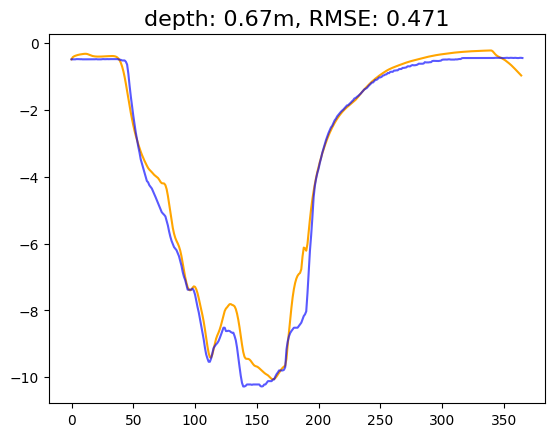

In [43]:
depth = "0.67m"


mineral_file = Path(f"~/gipl_experiments/gipl_{idx}/in/mineral.txt").expanduser()
with mineral_file.open() as file:
    contents = file.read()
    print(contents)


out_file = Path(f"~/gipl_experiments/gipl_{idx}").expanduser()
res=load_icalc(out_file)
rmse_value = np.sqrt(np.mean((res[depth] - df_meas[depth].iloc[:365])**2))


plt.plot(res[depth], color="orange")
plt.plot(df_meas[depth].loc[:365],alpha=0.65, color="blue")

plt.title(f'depth: {depth}, RMSE: {rmse_value:.3f}',fontsize=16 )

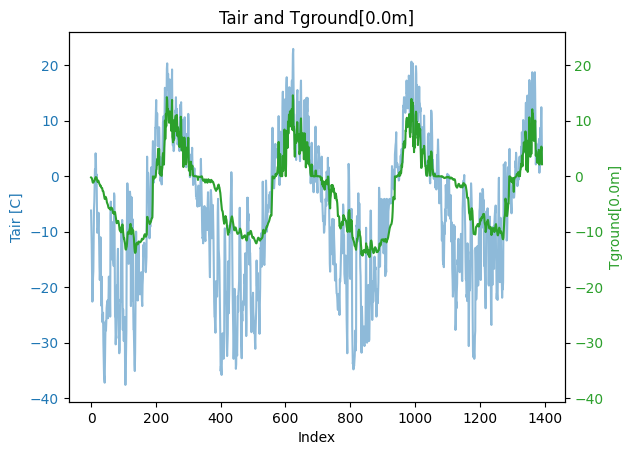

In [29]:
# Create the plot with two y-axes
fig, ax1 = plt.subplots()

# Plot the first dataset on the primary y-axis
ax1.plot(df_tair.index, df_tair['Tair [C]'], color='tab:blue', alpha=0.5)
ax1.set_xlabel('Index')
ax1.set_ylabel('Tair [C]', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Set the limits of the primary y-axis
ylim = ax1.get_ylim()

# Create a secondary y-axis and plot the second dataset
ax2 = ax1.twinx()
ax2.plot(df_meas.iloc[:1400,:1], color = "tab:green")
ax2.set_ylabel('Tground[0.0m]', color='tab:green')
ax2.tick_params(axis='y', labelcolor='tab:green')

# Set the same limits for the secondary y-axis
ax2.set_ylim(ylim)

# Add a title and show the plot
plt.title('Tair and Tground[0.0m]')
# plt.savefig('Tair_vs_Tground[0.0m].png', format='png')
plt.show()